In [2]:
import numpy as np
import matplotlib.pyplot as plt

---

# Zajęcia 2: Filozofia Data-Ink Maximization

Witaj na drugich zajęciach z wizualizacji danych! Dzisiaj zajmiemy się jedną z najważniejszych koncepcji w dziedzinie projektowania wykresów: **Data-Ink Ratio**, sformułowaną przez legendarnego statystyka, Edwarda Tufte'ego.

---

### Czym jest Data-Ink Ratio?
Zasada Tufte'ego mówi, że duża część „atramentu” (lub pikseli na ekranie) zużywana na wykresie nie niesie żadnych informacji o danych. Są to m.in. zbędne grube ramki, ciemne siatki w tle, cienie czy ozdobniki.

**Złota reguła:**
> Maksymalizuj udział atramentu niosącego dane (data-ink) w całkowitym zużyciu atramentu, o ile nie utrudnia to czytelności. (W skrócie: usuń wszystko, co nie jest danymi, a jeśli to zrobisz, wykres stanie się czytelniejszy).

---

Na dzisiejszych zajęciach wykonamy 3 „make-over'y” (metamorfozy) standardowych wykresów, opierając się na klasycznych przykładach z książki *The Visual Display of Quantitative Information*. Chętni i szybcy 2 zadania dodatkowe.

Na początek wygenerujmy dane, na których będziemy dziś pracować.

In [3]:
#@title Włącz kod do wczytywania danych

# Ustawienie ziarna losowości dla powtarzalności wyników
np.random.seed(42)

# Dane 1: Do wykresu punktowego (Scatter)
x_scatter = np.random.normal(50, 15, 30)
y_scatter = 0.7 * x_scatter + np.random.normal(0, 5, 30)

# Dane 2: Do wykresu słupkowego (Bar)
categories = ['A', 'B', 'C', 'D', 'E']
values_bar = [25, 45, 15, 30, 10]

# Dane 3: Do wykresu pudełkowego (Boxplot)
data_box =[
    np.random.normal(0.1*(k-3)*(k-6)*(k-10), np.abs(np.sin(k**2 + k**3)), 50) for k in range(1, 12)
]

## 1.1. Make-over: Redesign Wykresu Punktowego (Range-frame)
*(Inspiracja: Tufte, str. 130-132)*

Standardowy wykres punktowy posiada pełną, zamkniętą ramkę, która wykracza poza zakres danych. Tufte proponuje **Range-frame** – osie powinny zaczynać się tam, gdzie pierwszy punkt danych, i kończyć tam, gdzie ostatni.

## 1.2 **Narzędzia (funkcje i argumenty), których używamy:**

* `ax.scatter(x, y, color='black', s=20)` – rysuje punkty danych (używamy czarnego koloru i odpowiedniego rozmiaru punktu `s`).
* `ax.spines['top'].set_visible(False)` oraz `ax.spines['right'].set_visible(False)` – całkowicie ukrywają górną i prawą ramkę.
* `ax.spines['bottom'].set_bounds(min, max)` – genialna funkcja Matplotlib, która fizycznie "ucina" rysowanie osi (linii) dokładnie w punktach minimum i maksimum naszych danych.
* `ax.spines['left'].set_bounds(min, max)` – analogiczne ucięcie osi Y do najniższej i najwyższej wartości Y.

## 1.3 **Instrukcja krok po kroku:**
1. Na lewym subplocie (`ax1`) narysuj standardowy wykres za pomocą `ax1.scatter(x_scatter, y_scatter)`.
2. Na prawym subplocie (`ax2`) narysuj te same punkty, zmieniając kolor na `'black'`.
3. Usuń całkowicie górną i prawą ramkę na prawym wykresie, używając `ax2.spines['top'].set_visible(False)` oraz dla `right`.
4. Oblicz minimalne i maksymalne wartości dla x i y (np. `x_min = x_scatter.min()`).
5. Utnij dolną i lewą ramkę wykresu do tych wartości, używając metody `set_bounds(min, max)` na `ax2.spines['bottom']` i `ax2.spines['left']`.
6. **Kluczowy krok:** Ustaw znaczniki osi (ticks) *tylko* na skrajnych wartościach używając `ax2.set_xticks([x_min, x_max])` oraz `ax2.set_yticks([y_min, y_max])`.
7. Sformatuj etykiety do 1 miejsca po przecinku, np.: `ax2.set_xticklabels([f'{x_min:.1f}', f'{x_max:.1f}'])`.

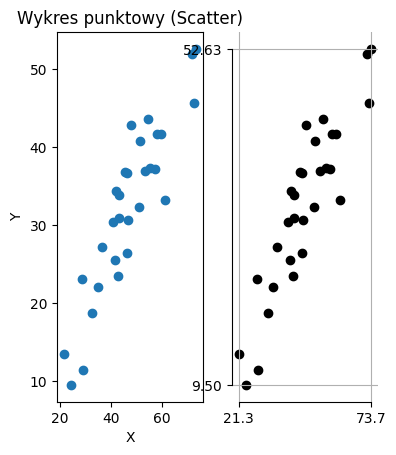

In [5]:
#@title 1.4 Twoje miejsce na uzupełniony kod
ax1 = plt.subplot(1, 3, 1)
ax1.scatter(x_scatter, y_scatter)
ax1.set_title('Wykres punktowy (Scatter)')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax2 = plt.subplot(1, 3, 2)
ax2.scatter(x_scatter, y_scatter, color='black')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
x_min, x_max = x_scatter.min(), x_scatter.max()
y_min, y_max = y_scatter.min(), y_scatter.max()
ax2.spines['bottom'].set_bounds(x_min, x_max)
ax2.spines['left'].set_bounds(y_min, y_max)
ax2.set_xticks([x_min, x_max])
ax2.set_yticks([y_min, y_max])
ax2.set_xticklabels([f'{x_min:.1f}', f'{x_max:.1f}'])
plt.grid(True)
plt.show()

## 2.1 Make-over: Bar Chart z „Białą Siatką”
*(Inspiracja: Tufte, str. 126-129)*

Tradycyjne słupki są obramowane czarnymi liniami i stoją na ciężkiej osi z ciemną siatką w tle. Tufte proponuje usunięcie czarnych linii. Zamiast czarnej siatki tła, nakładamy **cienką, białą siatkę bezpośrednio na słupki**. Tło tworzy słupek, a siatka (będąca brakiem atramentu) pozwala precyzyjnie odczytać wartość.

## 2.2 **Narzędzia (funkcje i argumenty), których używamy:**
* `ax.bar(x, height, color='gray', zorder=3)` – rysuje słupki. Parametr `color='gray'` tonuje wykres, a `zorder=3` sprawia, że słupki rysują się nad domyślnym tłem, ale pod spodem możemy manipulować siatką.
* `ax.spines['...'].set_visible(False)` – tym razem wyłączamy **wszystkie** ramki (top, right, left, bottom).
* `ax.tick_params(axis='both', length=0)` – usuwa małe "wąsy" (kreski) z osi X i Y, pozostawiając same etykiety tekstowe.
* `ax.grid(axis='y', color='white', linewidth=1.5, zorder=4)` – dodaje poziomą siatkę. Kluczowy jest `color='white'` oraz `zorder=4`, co sprawia, że białe linie są rysowane **na słupkach**, fizycznie je "przecinając".

## 2.3 **Instrukcja krok po kroku:**
1. Na `ax1` stwórz standardowy barplot używając `ax1.bar(categories, values_bar)`. Dodaj domyślną siatkę na osi Y (`ax1.grid(axis='y')`).
2. Na `ax2` narysuj słupki: `ax2.bar()`, ustawiając `color='gray'`.
3. Usuń wszystkie 4 ramki z `ax2`. Użyj pętli po liście `['top', 'right', 'left', 'bottom']` i dla każdej wykonaj `ax2.spines[ramka].set_visible(False)`.
4. Usuń małe pionowe i poziome kreski (wąsy) przy etykietach osi za pomocą `ax2.tick_params(axis='both', length=0)`.
5. **Kluczowy krok dla białej siatki:** W Matplotlib siatka domyślnie chowa się pod słupkami. Użyj metody `ax2.set_axisbelow(False)`, aby wymusić rysowanie osi i siatki na wierzchu wykresu.
6. Dodaj poziomą siatkę funkcją `ax2.grid()`. Ustaw `axis='y'`, `color='white'` oraz grubość `linewidth=2`.

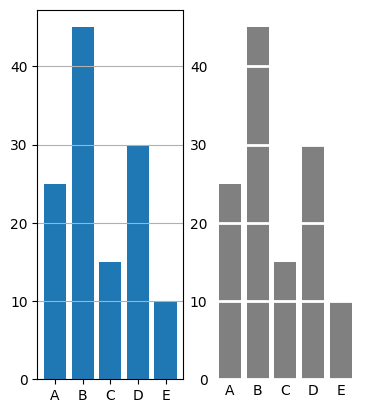

In [6]:
#@title 2.4 Twoje miejsce na uzupełniony kod
ax1 = plt.subplot(1, 3, 1)
ax1.bar(categories, values_bar)
ax1.grid(axis='y')
ax2 = plt.subplot(1, 3, 2)
ax2.bar(categories, values_bar, color='gray')
for spine in ['top', 'right', 'left', 'bottom']:
    ax2.spines[spine].set_visible(False)
ax2.tick_params(axis='both', length=0)
ax2.set_axisbelow(False)
ax2.grid(axis='y', color='white', linewidth=2)

## 3.1 Make-over: Minimalistyczny Boxplot (Quartile Plot)
*(Inspiracja: Tufte, str. 123-125)*

Klasyczny boxplot (wymyślony przez Johna Tukeya) składa się z zamkniętego pudełka i "wąsów" (whiskers). Pochłania dużo "atramentu". Tufte proponuje redukcję pudełka do minimum: jednej kropki oznaczającej medianę oraz dwóch cienkich linii reprezentujących kwartyle. Pomiędzy pierwszym a trzecim kwartylem (IQR) jest pusta przestrzeń.

## 3.2 **Narzędzia (funkcje i argumenty), których używamy:**
Do tego wykresu nie użyjemy wbudowanego `plt.boxplot`, ale zbudujemy go ręcznie, by mieć pełną kontrolę nad „atramentem”!
* `np.percentile(data,[25, 50, 75])` oraz `np.min()`, `np.max()` – do wyliczenia kluczowych statystyk dla każdej grupy danych (Minimum, Kwartyl 1, Mediana, Kwartyl 3, Maksimum).
* `ax.vlines(x, ymin, ymax, color='black', linewidth=1.5)` – rysuje pionową linię. Narysujemy dwie: dolną (od Min do Q1) i górną (od Q3 do Max).
* `ax.scatter(x, y, color='black', s=15, zorder=3)` – nanosi punkt w miejscu mediany.
* Odpowiednie użycie `ax.spines` do wyczyszczenia otoczenia.

## 3.3 **Instrukcja krok po kroku:**
1. Na `ax1` narysuj klasyczny boxplot dla listy `data_box` używając funkcji `ax1.boxplot()`.
2. Stwórz pętlę `for idx, data in enumerate(data_box, start=1):`, aby przejść przez każdą z 3 grup danych. Numer iteracji `idx` to miejsce rysowania na osi X (1, 2, 3).
3. Wewnątrz pętli: policz 25. (Q1), 50. (Mediana) i 75. (Q3) percentyl korzystając z `np.percentile(data,[25, 50, 75])`. Znajdź też min i max (`np.min(data)`, `np.max(data)`).
4. Nadal w pętli: Narysuj pionowe linie funkcją `ax2.vlines(x=idx, ymin, ymax, color='black')`. Zrób to dwukrotnie: najpierw od Min do Q1, potem od Q3 do Max.
5. Zaznacz medianę dodając pojedynczą kropkę: `ax2.scatter(idx, median, color='black', zorder=3)`.
6. Poza pętlą: oczyść układ! Wyłącz górną, prawą i lewą ramkę na `ax2`.
7. Przytnij dolną ramkę (bottom) od wartości 1 do 3 (`ax2.spines['bottom'].set_bounds(1, 3)`).
8. Wyłącz wąsy osi Y (`ax2.tick_params(axis='y', length=0)`) i ustaw podpisy osi X (`ax2.set_xticks([1, 2, 3])` oraz `ax2.set_xticklabels(...)`).

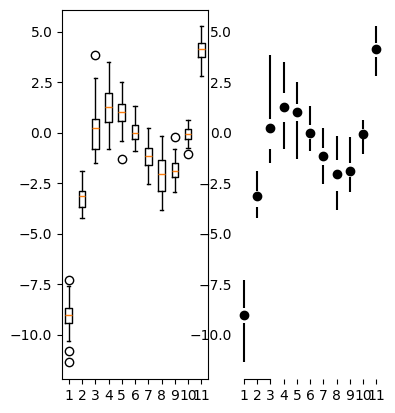

In [11]:
#@title 3.4 Twoje miejsce na uzupełniony kod
ax1 = plt.subplot(1, 3, 1)
ax1.boxplot(data_box)
ax2 = plt.subplot(1, 3, 2)
for idx, data in enumerate(data_box, start=1):
    Q1, M, Q3 = np.percentile(data, [25, 50, 75])
    min, max = np.min(data), np.max(data)
    ax2.vlines(x=idx, ymin=min, ymax=Q1, color='black')
    ax2.vlines(x=idx, ymin=Q3, ymax=max, color='black')
    ax2.scatter(idx, M, color='black', zorder=3)
for spine in ['top', 'right', 'left']:
    ax2.spines[spine].set_visible(False)
ax2.spines['bottom'].set_bounds(1, 3)
ax2.tick_params(axis='y', length=0)
ax2.set_xticks([i for i in range(1, 12)])
ax2.set_xticklabels([i for i in range(1, 12)])
plt.show()

## Zadania dodatkowe dla chętnych

### A. Dot-dash Plot (Scatter + Rug Plot)
*(Inspiracja: Tufte, str. 133)*

Zamiast ciągłych linii osi X i Y, możemy użyć "rug plot" (wykresu dywanikowego). Kreski wzdłuż krawędzi reprezentują rozkład jednowymiarowy (marginal distribution) zmiennych. Pozbywamy się całkowicie ramki osi!

**Narzędzia:**
* `ax.spines['...'].set_visible(False)` – usuwamy wszystkie 4 ramki.
* `ax.plot(x, y, marker='|', linestyle='', color='black')` – trik do rysowania osi X. `y` ustalamy jako wektor stałych wartości na poziomie `min(y_scatter)`, a znacznik `|` udaje kreski.
* `ax.plot(x, y, marker='_', linestyle='', color='black')` – analogicznie dla osi Y, znacznik `_` na poziomie `min(x_scatter)`.

**Instrukcja krok po kroku:**
1. Zrób standardowy, okienkowy scatter plot na `ax1`.
2. Narysuj czarne punkty `scatter` dla danych na `ax2`.
3. Używając pętli (podobnie jak w zadaniu 2), ukryj wszystkie 4 ramki `spines` na prawym wykresie.
4. Oblicz stałe wartości, na których oprzemy "dywaniki" tak, aby nie zasłaniały głównego wykresu. Np. `y_rug` to minimum `y_scatter` minus 2 (wielkość wektora musi być równa długości `x_scatter`). Zrób to samo dla `x_rug`.
5. Narysuj dywanik osi X używając `ax2.plot(x_scatter, y_rug)`. Jako parametry dodaj `marker='|'` oraz `linestyle=''`, aby rysowały się same pionowe kreseczki!
6. Narysuj dywanik osi Y używając `ax2.plot(x_rug, y_scatter)` ze znacznikiem `marker='_'`.
7. Ponieważ narysowaliśmy własne osie z kreseczek, ukryj domyślne numery i ticki podając do `ax2.tick_params()` argumenty: `bottom=False, left=False, labelbottom=False, labelleft=False`.

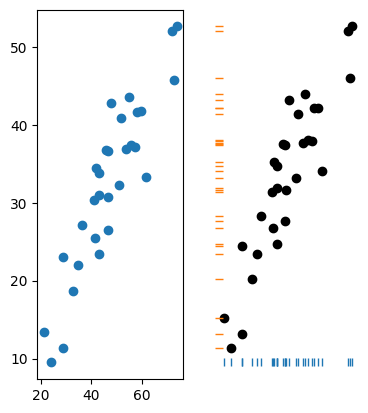

In [14]:
#@title Twoje miejsce na uzupełniony kod
ax1 = plt.subplot(1, 3, 1)
ax1.scatter(x_scatter, y_scatter)
ax2 = plt.subplot(1, 3, 2)
ax2.scatter(x_scatter, y_scatter, color='black')
for spine in ['top', 'right', 'left', 'bottom']:
    ax2.spines[spine].set_visible(False)
x_min, x_max = x_scatter.min(), x_scatter.max()
y_min, y_max = y_scatter.min(), y_scatter.max()
y_rug, x_rug = y_min - 2, x_min - 2
ax2.plot(x_scatter, [y_rug for _ in x_scatter], marker='|', linestyle='')
ax2.plot([x_rug for _ in y_scatter], y_scatter, marker='_', linestyle='')
ax2.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)
plt.show()

### B. Czyszczenie „Maszerujących Komarów” (Atomic Volume)
*(Inspiracja: Tufte, str. 102-105)*

Tufte krytykuje wykresy z tak gęstą siatką (szczególnie przerywaną), że siatka optycznie wibruje, co nazywa "maszerującą orkiestrą komarów" (precision marching band of mosquitoes).
Porównajmy tradycyjny, przeładowany wykres naukowy z wyczyszczoną, elegancką wersją, w której liczy się tylko trend.

**Narzędzia:**
* `plt.subplots(1, 2)` – tworzy dwa wykresy obok siebie do porównania.
* Wykres 1: włączamy wszystko co złe – `ax.grid(color='black', linestyle='--')`, zostawiamy pełne ramki.
* Wykres 2: nakładamy filozofię Tufte'ego – czyste tło `ax.grid(False)`, `ax.spines` ukryte (top, right), czytelna proporcja atramentu do danych.

**Instrukcja krok po kroku:**
1. Na `ax1` narysuj linię z punktami za pomocą `ax1.plot()`. Włącz gęstą, przerywaną siatkę: `ax1.grid(True, linestyle='--', color='black')`. Zostaw standardowe ramki. To nasz zły przykład.
2. Na `ax2` narysuj same czarne punkty (bez pełnej ciągłej linii dominującej wykres) za pomocą `ax2.plot(x, y, color='black', marker='o', linestyle='')`.
3. Zastosuj poznane już zasady: na `ax2` wyłącz `top` i `right` w `spines`.
4. Utnij ramki `bottom` i `left` używając metody `.set_bounds(min, max)` do zakresów wyznaczonych przez x i y.
5. Upewnij się, że siatka jest wyłączona: `ax2.grid(False)`.

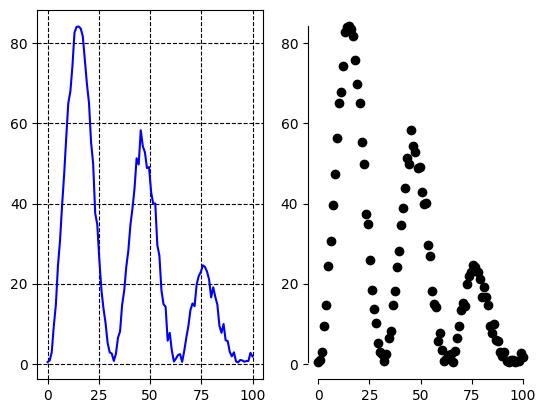

In [16]:
#@title Twoje miejsce na uzupełniony kod

# Generowanie danych dla wykresu (funkcja przypominająca dane spektrometryczne)
x = np.linspace(0, 100, 100)
y = np.abs(np.sin(x / 10) **2 * (100 - x) + np.random.normal(0, 2, 100))

ax1, ax2 = plt.subplot(1, 2, 1), plt.subplot(1, 2, 2)
ax1.grid(True, linestyle='--', color='black')
ax1.plot(x, y, color='blue')

ax2.plot(x, y, color='black', marker='o', linestyle='')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
ax2.spines['bottom'].set_bounds(x_min, x_max)
ax2.spines['left'].set_bounds(y_min, y_max)
ax2.grid(False)

plt.show()

## Podsumowanie

Pierwsza część teorii grafiki danych została ustalona. Główna idea, opisana w poprzednich rozdziałach, polega na tym, że większość atramentu na wykresie powinna odzwierciedlać zmienność danych. Teoria ta odnosi się do ogromnej różnorodności wizualizacji — codziennych wykresów naukowych, unikalnych rysunków Rogera Haywarda, przykładów z podręczników projektowania, prezentacji w gazetach, grafiki komputerowej, standardowych wykresów statystycznych, a także nowszych wynalazków Chernoffa i Tukeya.

Zaobserwowany wzrost efektywności – mierzony tym, jak duża część atramentu faktycznie niesie informacje – bywa niekiedy bardzo duży. W kilku przypadkach wskaźnik *data-ink ratio* wzrósł z 0.1 lub 0.2 do niemal 1.0. Przekształcone projekty są mniej zagracone i można je łatwiej pomniejszać bez utraty czytelności niż ich oryginały.

Ale czy przekształcone projekty są *lepsze*?

**(1)** Są one z definicji lepsze w świetle zasad tej teorii, ponieważ na jednostkę powierzchni i na jednostkę atramentu prezentowanych jest więcej informacji. Ma to istotne znaczenie; w rzeczywistości historia narzędzi do komunikowania informacji jest historią ciągłego wzrostu efektywności przekazu i produkcji.

**(2)** Wykresy niemal zawsze zyskują na jakości, gdy poddaje się je edycji, korekcie i testowaniu w zestawieniu z innymi opcjami projektowymi. Zasady maksymalizacji *data-ink* i usuwania zbędnego atramentu generują alternatywy projektowe, a także wyznaczają kierunek, w którym powinny podążać poprawki.

**(3)** Pozostaje kwestia odbiorców: czy patrząc na nowe projekty, będą oni zdezorientowani? Niektóre z nich, jak *range-frame*, są intuicyjne i tłumaczą się same. *Dot-dash-plot* jest nieco trudniejszy, choć nadal zawiera wszystkie standardowe informacje znane ze zwykłego wykresu punktowego (scatterplot). Odbiorca zdezorientowany ramką z kresek niczego nie traci, za to ten, kto ją zrozumie, zyskuje dodatkową wiedzę. Co więcej, częstym błędem w myśleniu o grafice statystycznej jest niedocenianie inteligencji odbiorców. Dlaczego by nie założyć, że skoro Ty to rozumiesz, to większość czytelników również to zrozumie? Wykresy powinny być równie inteligentne i wyrafinowane, co towarzyszący im tekst.

**(4)** Niektóre z nowych projektów mogą wydawać się dziwne, ale wynika to prawdopodobnie z faktu, że nie widzieliśmy ich wcześniej. Tradycyjne projekty wykresów statystycznych były oglądane tysiące razy przez niemal każdego z nas; z kolei *range-frame*, *dot-dash-plot*, białą siatkę, *quartile plot* czy *rugplot* widzieliśmy zaledwie kilka razy. Wraz z upowszechnieniem ich użycia, nowe projekty zaczną wyglądać równie naturalnie co stare.

---
> *Maksymalizacja wskaźnika data-ink (w granicach rozsądku) to tylko jeden z wymiarów złożonego i wieloaspektowego zadania, jakim jest projektowanie. Zasada ta pomaga w prowadzeniu eksperymentów z designem graficznym. Część z tych eksperymentów zakończy się sukcesem. Pozostaje jednak wiele innych czynników, które należy wziąć pod uwagę przy projektowaniu wykresów statystycznych – nie tylko kwestię efektywności, ale także złożoności, struktury, gęstości, a nawet piękna.*
>
> **~ Edward Tufte, The Visual Display of Quantitative Information, strony 136-137.**